In [2]:
import numpy as np
import matplotlib.pyplot as plt
from os.path import join as pjoin
from matplotlib.ticker import MaxNLocator
import pandas as pd
import importlib

from utils import OperonArgs

import fit_curves
importlib.reload(fit_curves)

import sys
sys.path.insert(0, '../literature_fits')
import attenuation_curves

from matplotlib import rcParams
rcParams['font.size'] = 12
rcParams['figure.dpi'] = 150
rcParams['axes.labelsize'] = 14
rcParams['axes.titlesize'] = 14
rcParams['legend.fontsize'] = 12
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12

# Pareto Fronts

conf: conf/iob_35.ini, ilen: 13

Reading from configuration file: conf/iob_35.ini

Reading from configuration file: conf/selection_1.ini
conf: conf/iob_44.ini, ilen: 43

Reading from configuration file: conf/iob_44.ini

Reading from configuration file: conf/selection_1.ini


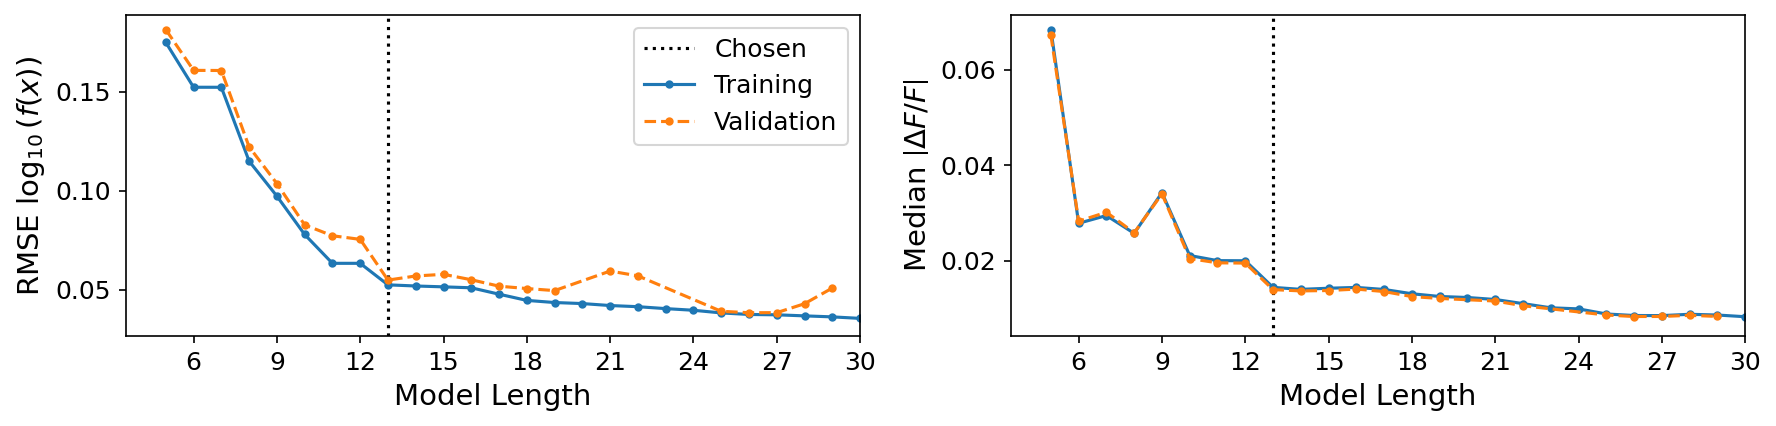

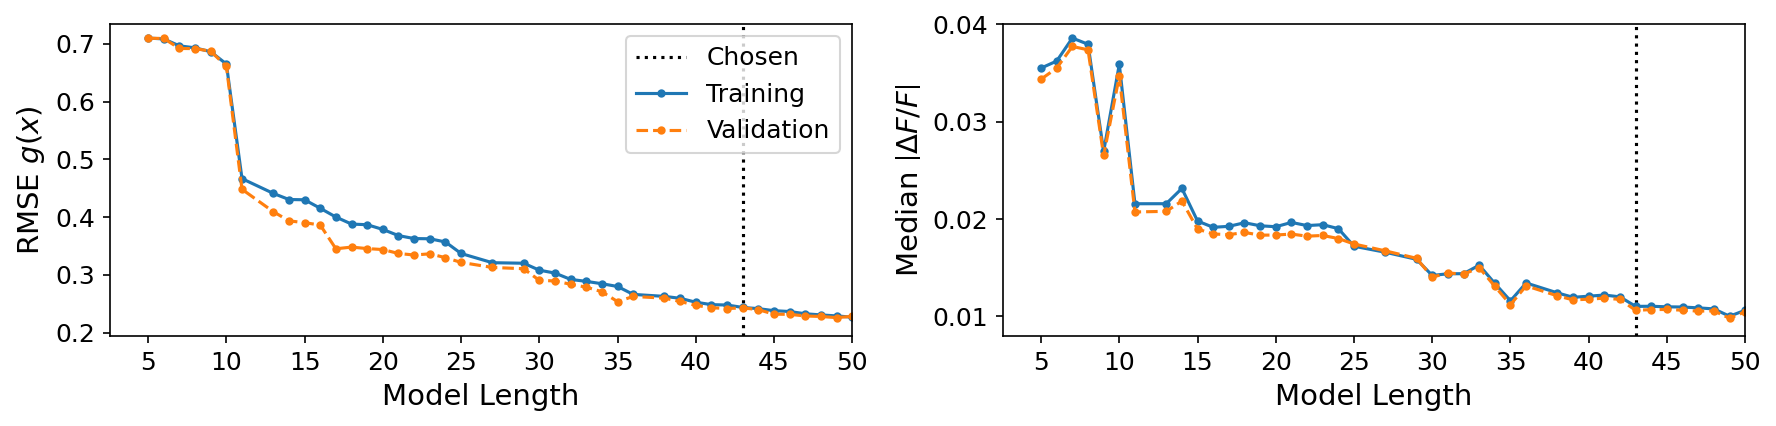

In [ ]:
all_run = [
    ('conf/iob_35.ini', 13, r'$\log_{10} (f(x))$'),
    ('conf/iob_44.ini', 43, r'$g(x)$'),
]

# cmap = plt.get_cmap('Set1')
cmap = plt.get_cmap('tab10')
fig_dir = 'figs/'

for ini_file, ilen, label in all_run:
    print(f'conf: {ini_file}, ilen: {ilen}')

    args = OperonArgs(ini_file)
    
    run_name = f'{args.in_param}_{str(args.version_num)}'
    out_dir = pjoin(args.fit_dir, run_name)
    fname = f'{out_dir}/{run_name}_fun.csv'
    df = pd.read_csv(fname, delimiter=';')
    eq_idx = list(df['Length']).index(ilen)
    
    fig, axs = plt.subplots(1, 2, figsize=(12, 3), sharex=True)

    axs[0].axvline(df['Length'].to_numpy()[eq_idx], ls=':', color='k', label='Chosen')
    m = np.isfinite(np.sqrt(df['MSE_train']))
    x = np.array(df['Length'][m])
    y = np.array(np.sqrt(df['MSE_train'])[m])
    i = np.argsort(x)
    axs[0].plot(x[i], y[i], marker='.', color=cmap(0), label='Training')
    m = np.isfinite(np.sqrt(df['MSE_val']))
    x = np.array(df['Length'][m])
    y = np.array(np.sqrt(df['MSE_val'])[m])
    i = np.argsort(x)
    axs[0].plot(x[i], y[i], marker='.', ls='--', color=cmap(1), label='Validation')
    if axs[0].get_xlim()[1] > args.max_length:
        axs[0].set_xlim(None, args.max_length)
    axs[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    axs[0].set_ylabel('RMSE ' + label)

    axs[1].axvline(df['Length'].to_numpy()[eq_idx], ls=':', color='k', label='Chosen')
    m = np.isfinite(df['MedAE_train_F'])
    x = np.array(df['Length'][m])
    y = np.array(df['MedAE_train_F'][m])
    i = np.argsort(x)
    axs[1].plot(x[i], y[i], marker='.', color=cmap(0), label='Training')
    m = np.isfinite(df['MedAE_val_F'])
    x = np.array(df['Length'][m])
    y = np.array(df['MedAE_val_F'])[m]
    i = np.argsort(x)
    axs[1].plot(x[i], y[i], marker='.', ls='--', color=cmap(1), label='Validation')
    if axs[1].get_xlim()[1] > args.max_length:
        axs[1].set_xlim(None, args.max_length)
    axs[1].xaxis.set_major_locator(MaxNLocator(integer=True))
    axs[1].set_ylabel('Median ' + r'$\left| \Delta F / F \right|$')

    for ax in axs:
        ax.set_ylim(max(0, ax.get_ylim()[0]), None)
        ax.set_xlabel('Model Length')
        ax.legend(loc='upper right')
    
    fig.align_labels()
    fig.tight_layout()

    fig.savefig(pjoin(fig_dir, f'{run_name}_results.pdf'), bbox_inches='tight')

# Example Galaxy


Reading from configuration file: conf/iob_44.ini

Reading from configuration file: conf/selection_1.ini
Loaded original data from /mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/val_data_v1.csv with 736 galaxies.
4-parameter fit: [ 1.88326957e+00 -8.44349221e-04  7.63115595e-01  1.84017439e-03]
2-parameter fit: [0.27313668 0.47221578]
New model fit: [  0.10891688 -12.89600062  20.31176781   0.74637668]


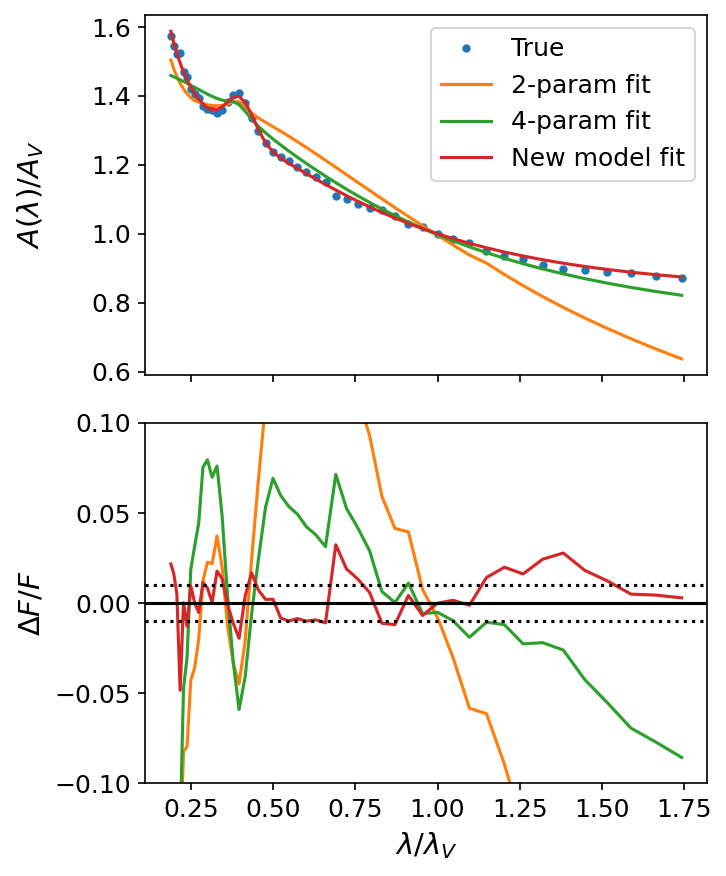

In [58]:
ini_file = 'conf/iob_44.ini' # MW

args = OperonArgs(ini_file)

lam_min = args.lam_min 
lam_max = args.lam_max

# name = 'train'
# igal = 1426

name = 'val'
igal = 91

x, ytrue, _, _, _, Av = fit_curves.load_data(args, name)
run_name = f'{args.in_param}_{str(args.version_num)}'
fname_opt = f'{args.fit_dir}/{run_name}/{run_name}_opt_results_{name}.csv'
df_opt = pd.read_csv(fname_opt)
lam = x * args.lambda_V

m = (lam >= lam_min) & (lam <= lam_max)
x = x[m]
lam = lam[m]
ytrue = ytrue[igal,m]
Av = Av[igal]

popt_4par = df_opt[['4par_p0', '4par_p1', '4par_p2', '4par_p3']].values[igal]
popt_2par = df_opt[['2par_B', '2par_delta']].values[igal]
popt_new = df_opt[['newpar_reparam_A0', 'newpar_reparam_A1', 'newpar_reparam_A2', 'newpar_reparam_A3']].values[igal]

print('4-parameter fit:', popt_4par)
print('2-parameter fit:', popt_2par)
print('New model fit:', popt_new)

ypred_2par = attenuation_curves.Att_Curve_2param(1e4*lam, *popt_2par)
ypred_4par = attenuation_curves.Li_08_fit_noratio(lam, *popt_4par)
ypred_new = fit_curves.new_model_reparam(x, *popt_new)

# # Calculate dF/F errors
dF_F_2par = 10. ** (0.4 * Av * (ypred_2par - ytrue)) - 1.0
dF_F_4par = 10. ** (0.4 * Av * (ypred_4par - ytrue)) - 1.0
dF_F_new = 10. ** (0.4 * Av * (ypred_new - ytrue)) - 1.0

fig, axs = plt.subplots(2, 1, figsize=(5,6), sharex=True)
axs[0].plot(x, ytrue, '.', label='True')
axs[0].plot(x, ypred_2par, label='2-param fit')
axs[0].plot(x, ypred_4par, label='4-param fit')
axs[0].plot(x, ypred_new, label='New model fit')
axs[0].legend()
axs[0].set_ylabel(r'$A(\lambda) / A_V$')
axs[1].plot(x, dF_F_2par, color='C1')
axs[1].plot(x, dF_F_4par, color='C2')
axs[1].plot(x, dF_F_new, color='C3')
axs[1].set_ylabel(r'$\Delta F / F$')

ylim = axs[1].get_ylim()
ylim = (max(ylim[0], -0.1), min(ylim[1], 0.1))
axs[1].set_ylim(ylim)

axs[1].axhline(0., color='k', ls='-')
axs[1].axhline(0.01, color='k', ls=':')
axs[1].axhline(-0.01, color='k', ls=':')

axs[1].set_xlabel(r'$\lambda / \lambda_V$')

fig.align_labels()
fig.tight_layout()
fig.savefig('figs/example_fit.pdf', bbox_inches='tight')


# SR Strategy


Reading from configuration file: conf/iob_44.ini

Reading from configuration file: conf/selection_1.ini
Loaded original data from /mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/train_data_v1.csv with 1473 galaxies.
4-parameter fit: [ 3.41480524  1.88172107 -0.9980565   0.07887548]
2-parameter fit: [ 4.80912893 -0.24937378]
New model fit: [  0.96370752 -95.63419375 529.14320434   2.66056906]


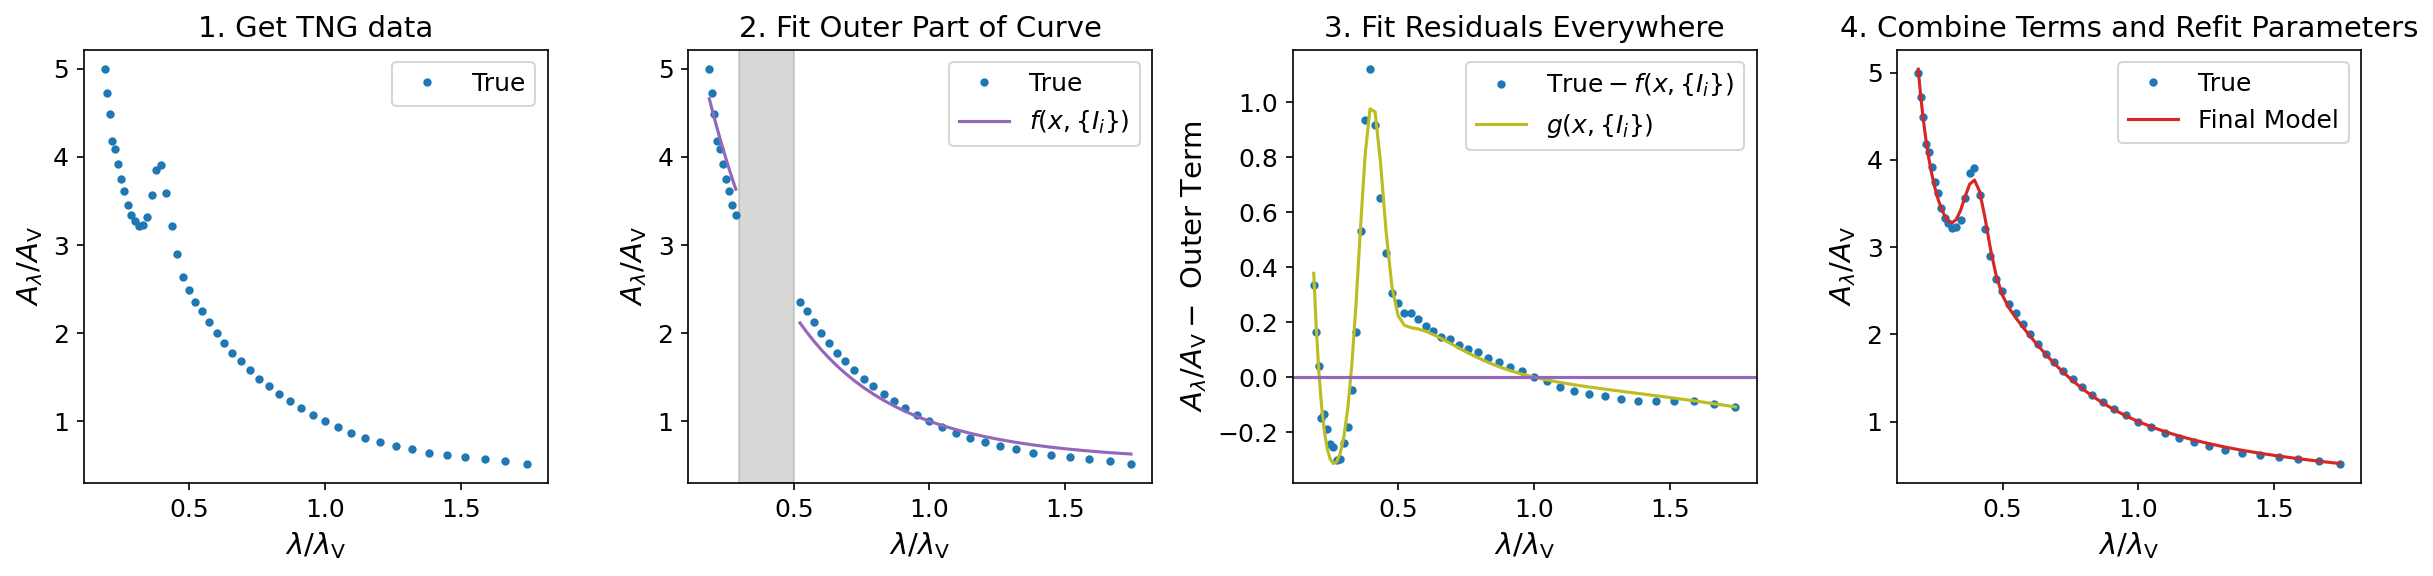

In [56]:
ini_file = 'conf/iob_44.ini' # MW

args = OperonArgs(ini_file)

lam_min = args.lam_min 
lam_max = args.lam_max

# name = 'val'
# igal = 91
name = 'train'
igal = 10

x_bump_min = args.lam_bump_min / args.lambda_V
x_bump_max = args.lam_bump_max / args.lambda_V

x, ytrue, _, _, _, Av = fit_curves.load_data(args, name)
run_name = f'{args.in_param}_{str(args.version_num)}'
fname_opt = f'{args.fit_dir}/{run_name}/{run_name}_opt_results_{name}.csv'
df_opt = pd.read_csv(fname_opt)
lam = x * args.lambda_V

m = (lam >= lam_min) & (lam <= lam_max)
x = x[m]
lam = lam[m]
ytrue = ytrue[igal,m]
Av = Av[igal]

popt_4par = df_opt[['4par_p0', '4par_p1', '4par_p2', '4par_p3']].values[igal]
popt_2par = df_opt[['2par_B', '2par_delta']].values[igal]
popt_new = df_opt[['newpar_reparam_A0', 'newpar_reparam_A1', 'newpar_reparam_A2', 'newpar_reparam_A3']].values[igal]

print('4-parameter fit:', popt_4par)
print('2-parameter fit:', popt_2par)
print('New model fit:', popt_new)

def new_model_reparam_outer(x, A0, A1, A2, A3):
    """
    The model to be optimised

    Args:
        x: (N,) input array of lamda/lambda_V
        A0, A1, A2, A3: Scalars representing the A parameters for this galaxy

    Returns:
        y: (N,) output array of predicted A(lambda)/A_V
    """

    c = [0.4002, 285.6, 0.2092, 9.223, 1.016]

    y = np.exp(A3 * (np.tanh(c[4]) - np.tanh(c[4] * x)))

    return y

ypred_2par = attenuation_curves.Att_Curve_2param(1e4*lam, *popt_2par)
ypred_4par = attenuation_curves.Li_08_fit_noratio(lam, *popt_4par)
ypred_new = fit_curves.new_model_reparam(x, *popt_new)
ypred_new_outer = new_model_reparam_outer(x, *popt_new)

fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharex=True)

axs[0].plot(x, ytrue, '.', label='True', color='C0')
axs[0].set_title('1. Get TNG data')

m = (x <= x_bump_min)
axs[1].plot(x[m], ytrue[m], '.', label='True', color='C0')
axs[1].plot(x[m], ypred_new_outer[m], label=r'$f(x, \{I_i\})$', color='C4')
m = (x >= x_bump_max)
axs[1].plot(x[m], ytrue[m], '.', color='C0')
axs[1].plot(x[m], ypred_new_outer[m], color='C4')
# Add verticle gray bands in the bumpy region
axs[1].axvspan(x_bump_min, x_bump_max, color='gray', alpha=0.3)
axs[1].set_title('2. Fit Outer Part of Curve')

res_true = ytrue - ypred_new_outer
res_pred = ypred_new - ypred_new_outer
axs[2].plot(x, res_true, '.', label=r'${\rm True}- f(x, \{I_i\})$', color='C0')
axs[2].plot(x, res_pred, label=r'$g(x, \{I_i\})$', color='C8')
axs[2].axhline(0., color='C4', ls='-')
axs[2].set_title('3. Fit Residuals Everywhere')

axs[3].plot(x, ytrue, '.', label='True', color='C0')
axs[3].plot(x, ypred_new, label='Final Model', color='C3')
axs[3].set_title('4. Combine Terms and Refit Parameters')

for ax in axs:
    ax.set_xlabel(r'$\lambda / \lambda_{\rm V}$')
    ax.legend(loc='upper right')

for ax in [axs[0], axs[1], axs[3]]:
    ax.set_ylabel(r'$A_\lambda / A_{\rm V}$')
axs[2].set_ylabel(r'$A_\lambda / A_{\rm V} - $ Outer Term')

fig.align_labels()
fig.tight_layout()
fig.savefig('figs/fitting_procedure.png', bbox_inches='tight', dpi=150)
